![Banner](banner.jpg)

# Laboratorio 10: Redes Recurrentes — LSTM y GRU

## 1. Introducción

### ¿Qué son las Redes Neuronales Recurrentes (RNN)?

Las **redes neuronales recurrentes** son una familia de arquitecturas de deep learning diseñadas
para procesar **datos secuenciales**, como series de tiempo, texto o audio. A diferencia de las
redes feedforward tradicionales, las RNN mantienen un **estado oculto** que actúa como una
"memoria" de los pasos anteriores en la secuencia.

Sin embargo, las RNN simples sufren del problema del **desvanecimiento del gradiente**
(vanishing gradient), lo que dificulta aprender dependencias a largo plazo. Para resolver
esto, se han propuesto dos arquitecturas clave:

### LSTM (Long Short-Term Memory)

Las redes **LSTM** fueron propuestas por Hochreiter & Schmidhuber (1997). Su idea central
es agregar un **estado de celda** (cell state) que fluye a lo largo de la secuencia,
regulado por tres compuertas:

1. **Forget gate**: decide qué información descartar del estado de celda.
2. **Input gate**: decide qué información nueva agregar al estado de celda.
3. **Output gate**: decide qué parte del estado de celda se usa como salida.

Gracias a estas compuertas, las LSTM pueden aprender **dependencias a largo plazo**
sin sufrir tanto del desvanecimiento del gradiente.

### GRU (Gated Recurrent Unit)

Las redes **GRU** (Cho et al., 2014) son una variante simplificada de las LSTM. En lugar
de tres compuertas, usan solo dos:

1. **Reset gate**: controla cuánto del estado anterior se olvida.
2. **Update gate**: controla cuánto del nuevo estado se mezcla con el anterior.

Las GRU tienen **menos parámetros** que las LSTM, lo que las hace más rápidas de entrenar
y, en muchos casos, logran un desempeño similar.

### Objetivo de esta práctica

En este laboratorio usaremos datos financieros de acciones tecnológicas para:
- Construir y entrenar un modelo **LSTM** para predicción de series de tiempo.
- Evaluar su desempeño en la predicción del precio de cierre de una acción.
- Visualizar las predicciones vs. valores reales.

## 2. Preparación del entorno

In [1]:
!pip install yfinance pandas-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 116.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 118.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [yfinance]/13 [curl_cffi]]


In [2]:
# para settear tiempos
from datetime import datetime

import pandas as pd
import yfinance as yf

## 3. Carga del dataset

Para este problema usaremos la librería **yfinance**, la cual retorna los valores
de stock para diferentes empresas. En este caso tenemos los valores de:
- **AAPL** (Apple)
- **GOOG** (Google/Alphabet)
- **MSFT** (Microsoft)
- **AMZN** (Amazon)

Usaremos los registros de los últimos **3 años** como ejemplo.

In [3]:
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']

# Asignamos el rango de fechas en las que queremos consultar los datos
end = datetime(year=2021, month=12, day=31)
start = datetime(end.year - 3, end.month, end.day)

tech_stock = yf.download(tech_list, start, end)

[*********************100%***********************]  4 of 4 completed


In [4]:
tech_stock = pd.DataFrame(
    {f'{price_type}_{ticker}': tech_stock[(price_type, ticker)] for price_type, ticker in tech_stock.columns},
    index=tech_stock.index,
)

## 4. Exploración de datos

En este dataset podemos ver que por cada stock, medidos una vez al día:
- **High**: el precio máximo del stock durante el día
- **Low**: el precio mínimo del stock en el día
- **Open**: el precio al comienzo del día
- **Close**: el precio al final del día
- **Volume**: el volumen de transacciones del día

In [5]:
tech_stock.head(10)

,Close_AAPL,Close_AMZN,Close_GOOG,Close_MSFT,High_AAPL,High_AMZN,High_GOOG,High_MSFT,Low_AAPL,Low_AMZN,Low_GOOG,Low_MSFT,Open_AAPL,Open_AMZN,Open_GOOG,Open_MSFT,Volume_AAPL,Volume_AMZN,Volume_GOOG,Volume_MSFT
Date,,,,,,,,,,,,,,,,,,,,
2018-12-31,37.460976,75.098503,51.358849,94.817238,37.845701,76.038002,52.206390,95.592058,37.161742,74.349998,50.762745,93.762367,37.648588,75.540001,52.120101,94.555854,140014000,139090000,29866000,33173800
2019-01-02,37.503727,76.956497,51.866680,94.397141,37.724590,77.667999,52.187547,94.985253,36.627404,73.046501,50.371952,92.362075,36.784146,73.260002,50.414601,92.931521,148158800,159662000,30652000,35329300
2019-01-03,33.768078,75.014000,50.389305,90.924484,34.606402,76.900002,52.418642,93.528995,33.722955,74.855499,50.290613,90.737777,34.193175,76.000504,51.626148,93.444975,365248800,139512000,36822000,42579100
2019-01-04,35.209610,78.769501,53.099548,95.153282,35.278483,79.699997,53.105996,95.694723,34.150426,75.915497,50.952575,92.352734,34.323790,76.500000,51.209071,93.090213,234428400,183652000,41878000,44060600
2019-01-07,35.131245,81.475502,52.984497,95.274673,35.344984,81.727997,53.262715,96.404227,34.649149,79.459503,52.308547,94.266481,35.314110,80.115501,53.138733,94.882598,219111200,159864000,39638000,35656100
2019-01-08,35.800957,82.829002,53.375793,95.965454,36.055068,83.830498,53.786424,97.057666,35.271365,80.830498,52.594708,94.947918,35.518348,83.234497,53.367364,96.189496,164101200,177628000,35298000,31514400
2019-01-09,36.408916,82.971001,53.295448,97.337708,36.698649,83.389999,53.690702,97.907153,35.534971,82.070000,52.885809,96.376187,35.929195,82.649002,53.642101,96.954970,180396400,126976000,23986000,32280800
2019-01-10,36.525284,82.810997,53.080711,96.712250,36.565656,83.162498,53.121378,96.852279,35.827076,81.081001,52.454853,95.573359,36.216552,82.050499,52.948299,96.357516,143122800,130154000,29128000,30067600
2019-01-11,36.166687,82.028000,52.429066,95.965454,36.501543,83.014503,52.755635,96.562904,35.981448,81.810997,51.997111,94.882572,36.306806,82.027496,52.726126,96.329525,108092800,93724000,30416000,28314200


### Selección del target

Tomamos uno de los stocks (Apple) como variable objetivo que vamos a predecir.

In [6]:
target_col = 'Close_AAPL'
target = tech_stock[target_col]

### Visualización de la serie de tiempo

Graficamos la variación de los precios de cierre de Apple a lo largo del tiempo seleccionado.

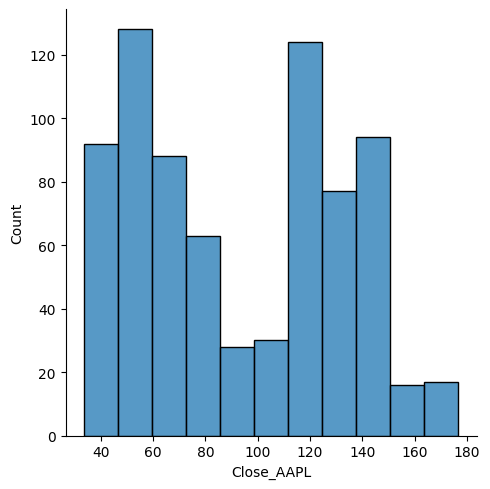

<Axes: xlabel='Date', ylabel='Close_AAPL'>

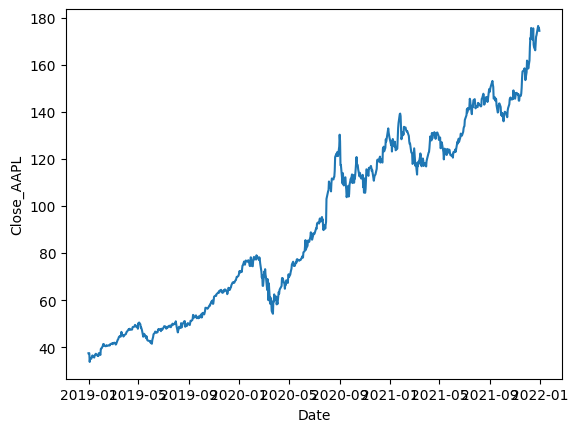

In [7]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.displot(target)
plt.show()

sns.lineplot(target)

## 5. Preparación de datos

### División del dataset

Dividimos los datos en:
- **60%** para entrenamiento
- **20%** para validación
- **20%** para test

Es importante que en series de tiempo la división sea **secuencial** (no aleatoria),
ya que queremos predecir el futuro a partir del pasado.

In [8]:
num_train_samples = int(0.6 * len(tech_stock))  # 60% de los datos
num_val_samples = int(0.2 * len(tech_stock))  # 20% de los datos
num_test_samples = len(tech_stock) - num_train_samples - num_val_samples  # los datos restantes
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 454
num_val_samples: 151
num_test_samples: 152


### Estandarización

Estandarizamos los datos restando la media y dividiendo por la desviación estándar
del conjunto de entrenamiento.

In [9]:
# Estandarizacion de los datos
mean = tech_stock[:num_train_samples].mean(axis=0)
tech_stock -= mean
std = tech_stock[:num_train_samples].std(axis=0)
tech_stock /= std

In [10]:
# Dividir los datos
train_data = tech_stock[:num_train_samples]
valid_data = tech_stock[num_train_samples:num_train_samples + num_val_samples]
test_data = tech_stock[num_train_samples + num_val_samples:]

### Creación de datasets con ventanas temporales

Usaremos la función `timeseries_dataset_from_array` para crear los datasets.

La idea general es que al proporcionar una matriz de datos de series temporales,
`timeseries_dataset_from_array` genera **ventanas deslizantes** extraídas de la serie temporal original.

Por ejemplo, si nuestros datos son `[0 1 2 3 4 5 6]` y `sequence_length=3`,
se generarán las siguientes muestras: `[0 1 2]`, `[1 2 3]`, `[2 3 4]`, `[3 4 5]`, `[4 5 6]`.

- **sequence_length**: Longitud de las secuencias de entrada (número de pasos de tiempo)
- **batch_size**: Número de secuencias por batch

Documentación: https://www.tensorflow.org/api_docs/python/tf/keras/utils/timeseries_dataset_from_array

In [11]:
import tensorflow as tf

batch_size = 8
sequence_length = 60


def make_dataset(data, shuffle=False):
    return tf.keras.utils.timeseries_dataset_from_array(
        data=data.drop(columns=[target_col]).values[:-1],
        targets=data[target_col].values[sequence_length:],
        sequence_length=sequence_length,
        batch_size=batch_size,
        shuffle=shuffle
    )


train_dataset = make_dataset(train_data, shuffle=True)
valid_dataset = make_dataset(valid_data, shuffle=False)
test_dataset = make_dataset(test_data, shuffle=False)

I0000 00:00:1777045843.061135   11935 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777045843.091147   11935 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777045843.750901   11935 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1777045844.292489   11935 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel bi

El código anterior produce un dataset en el cual la variable independiente **X** es los valores del stock
en un periodo de **60 días** y el target es el precio de cierre de Apple en el día después de la secuencia.

In [12]:
for i, (samples, target) in zip(range(3), train_dataset):
    print(f'sample shape: {samples.shape}, target shape: {target.shape}')
    if i == 2:
        print(samples)
        print(target)

sample shape: (8, 60, 19), target shape: (8,)
sample shape: (8, 60, 19), target shape: (8,)
sample shape: (8, 60, 19), target shape: (8,)
tf.Tensor(
[[[ 2.02646232e+00  1.60577188e+00  1.70483294e+00 ...  5.52400441e-01
    2.78579462e-01 -3.48900588e-01]
  [ 1.84519577e+00  1.41211749e+00  1.51443947e+00 ...  1.71345687e+00
    2.65166925e-01  4.42013412e-01]
  [ 1.80743193e+00  1.47097675e+00  1.55136392e+00 ...  1.45961868e+00
   -8.89782443e-02  4.06045940e-01]
  ...
  [ 1.92965445e+00  1.14621989e+00  1.62314953e+00 ...  2.45871982e-01
    6.89916363e-02  1.57177224e-01]
  [ 2.06660542e+00  1.27674807e+00  1.68474342e+00 ...  2.85259772e-01
    1.74530690e-01 -2.84029501e-01]
  [ 1.88484792e+00  1.07500078e+00  1.50343169e+00 ...  6.18445139e-01
   -4.96638082e-01  1.12578352e-01]]

 [[-8.87810894e-01 -1.35933601e+00 -1.55275747e+00 ...  2.31674479e+00
    1.54750585e-01  4.08066620e-03]
  [-8.82448493e-01 -1.36965647e+00 -1.51119950e+00 ...  1.00073534e+00
   -6.11525268e-01  5.4

## 6. Modelo LSTM

Construimos un modelo secuencial con:
1. Una capa **LSTM** con 64 unidades y `return_sequences=True` (para pasar la secuencia completa a la siguiente capa)
2. Una segunda capa **LSTM** con 32 unidades y `return_sequences=False`
3. Una capa **Dense** con 32 neuronas y activación ReLU
4. Una capa de **salida** con 1 neurona (predicción del precio)

Usamos **MAE** (Mean Absolute Error) como función de pérdida.

In [13]:
number_of_features = train_data.shape[1] - 1

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30, number_of_features)),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile
model.compile(
    optimizer='adam',
    loss='mae',  # Mean Absolute Error
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,009 (136.75 KB)

 Trainable params: 35,009 (136.75 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento

Entrenamos el modelo por **100 épocas**. Observaremos las curvas de pérdida
para detectar posible sobreajuste.

In [14]:
# Train the model
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=100
)

Epoch 1/100


I0000 00:00:1777045888.279582   12080 cuda_dnn.cc:461] Loaded cuDNN version 91900


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2849 - mae: 0.2849 - val_loss: 1.2063 - val_mae: 1.2063
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1047 - mae: 0.1047 - val_loss: 0.9727 - val_mae: 0.9727
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1166 - mae: 0.1166 - val_loss: 0.4170 - val_mae: 0.4170
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1080 - mae: 0.1080 - val_loss: 0.9348 - val_mae: 0.9348
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0828 - mae: 0.0828 - val_loss: 1.2540 - val_mae: 1.2540
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0809 - mae: 0.0809 - val_loss: 1.2076 - val_mae: 1.2076
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0724 - mae: 0.0724 - val_loss: 1.4538 - val_mae: 1.4538
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0766 - mae: 0.0766 - val_loss: 0.9489 - val_mae: 0.9489
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0803 - mae: 0.0

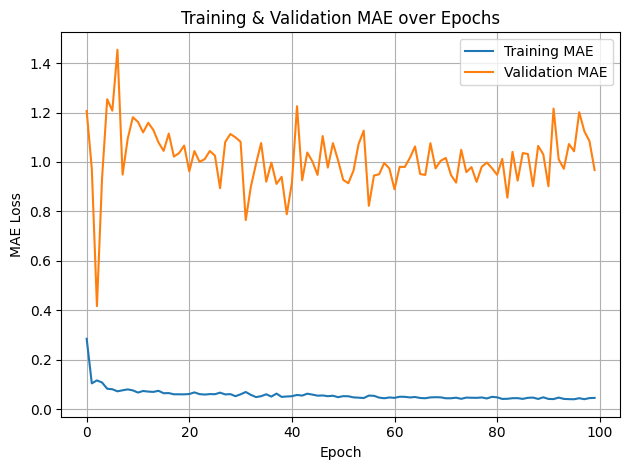

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training MAE')
plt.plot(history.history['val_loss'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.title('Training & Validation MAE over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. Evaluación del modelo

Evaluamos el modelo en el conjunto de test y generamos predicciones
para comparar visualmente con los valores reales.

In [16]:
test_loss, test_mae = model.evaluate(test_dataset)

print(f"Test MAE: {test_mae:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5346 - mae: 2.5346 
Test MAE: 2.5346


In [17]:
import numpy as np

# Obtener todos los inputs y targets del valid_dataset
y_true = []
y_pred = []

for x_batch, y_batch in valid_dataset:
    preds = model.predict(x_batch, verbose=0)
    y_true.extend(y_batch.numpy().flatten())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

## 9. Visualización de resultados

Comparamos las predicciones del modelo LSTM contra los valores reales
del conjunto de validación.

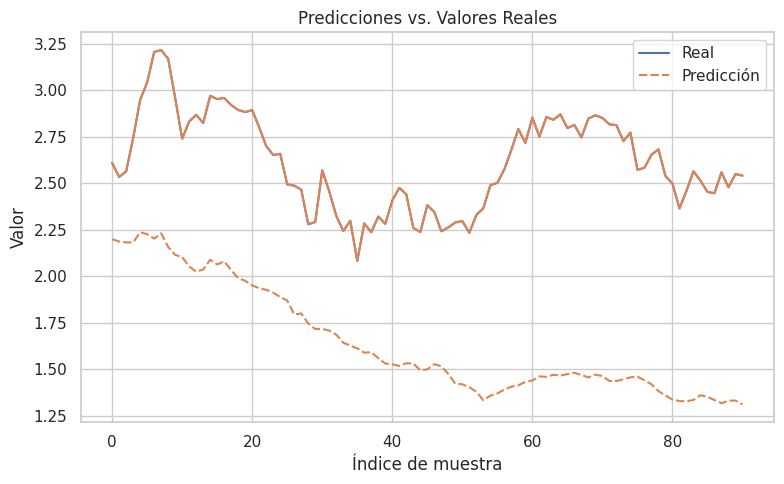

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Crear DataFrame para graficar
df_plot = pd.DataFrame({
    "Real": y_true,
    "Predicción": y_pred
})

# Plot real vs predicho
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_plot)
sns.lineplot(x=df_plot.index, y="Real", data=df_plot)

plt.title("Predicciones vs. Valores Reales")
plt.xlabel("Índice de muestra")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Análisis del error

En este caso podemos ver que las predicciones pueden tener un sesgo,
esto se debe a que los datos de entrenamiento se tomaron de una sección con
un promedio diferente al de validación. Este es un fenómeno común en series de
tiempo financieras, donde la distribución de los datos cambia a lo largo del tiempo.